In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import os
import json
import joblib
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split

import spacy
from textstat import flesch_reading_ease
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from collections import Counter
from urllib.parse import urlparse
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix

import lime
from lime.lime_text import LimeTextExplainer

warnings.filterwarnings('ignore')
tqdm.pandas()

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [3]:
PROCESSED_DATA_PATH = Path("data/processed/df_cleaned_phase_2.csv")
FINAL_MODEL_PATH = Path("models/final_fake_news_detector")
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

# Load cleaned data from 2
if PROCESSED_DATA_PATH.exists():
    print("Loading cleaned data from Phase 2...")
    df_cleaned = pd.read_csv(PROCESSED_DATA_PATH)
    print(f"Loaded {len(df_cleaned)} records.")
else:
    raise FileNotFoundError(f"Cleaned data not found at {PROCESSED_DATA_PATH}. Please run Phase 2 first.")

# --- Load Trained DistilBERT Model and Tokenizer from Phase 2 ---
if FINAL_MODEL_PATH.exists():
    print("Loading fine-tuned DistilBERT model from Phase 2...")
    distilbert_model = DistilBertForSequenceClassification.from_pretrained(FINAL_MODEL_PATH)
    tokenizer = DistilBertTokenizer.from_pretrained(FINAL_MODEL_PATH)
    distilbert_model.to(device)
    distilbert_model.eval() # Set to evaluation mode
    print("Model and tokenizer loaded successfully.")
else:
    raise FileNotFoundError(f"Trained model not found at {FINAL_MODEL_PATH}. Please run Phase 2 first.")

# --- Recreate the same data splits as Phase 2 for consistency ---
print("\nRecreating data splits from Phase 2...")
texts = df_cleaned['text_cleaned'].tolist()
labels = df_cleaned['label'].tolist()

# Split data: 70% train, 15% validation, 15% test
X_temp, X_test_texts, y_temp, y_test = train_test_split(
    texts, labels, test_size=0.15, random_state=42, stratify=labels
)

X_train_texts, X_val_texts, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)

print(f"Train set: {len(X_train_texts):,} samples")
print(f"Validation set: {len(X_val_texts):,} samples")
print(f"Test set: {len(X_test_texts):,} samples")

Loading cleaned data from Phase 2...
Loaded 35307 records.
Loading fine-tuned DistilBERT model from Phase 2...
Model and tokenizer loaded successfully.

Recreating data splits from Phase 2...
Train set: 24,728 samples
Validation set: 5,282 samples
Test set: 5,297 samples


In [4]:
# --- Block 1: Advanced Feature Extractor Class ---
print("Initializing Advanced Feature Extractor...")
nlp = spacy.load("en_core_web_lg")

class AdvancedFeatureExtractor:
    """Extracts advanced NLP features for fake news detection."""
    def __init__(self):
        self.nlp = nlp
        self.sentiment_analyzer = SentimentIntensityAnalyzer()
        self.sensational_words = {
            'shocking', 'unbelievable', 'amazing', 'incredible', 'outrageous',
            'scandal', 'exposed', 'revealed', 'secret', 'hidden', 'truth',
            'must see', "you won't believe", 'exclusive', 'breaking', 'hate'
        }
        self.reliable_sources = {
            'bbc.com', 'reuters.com', 'apnews.com', 'npr.org',
            'thehindu.com', 'indianexpress.com', 'ndtv.com'
        }

    def extract_linguistic_features(self, text):
        doc = self.nlp(text)
        pos_counts = Counter(token.pos_ for token in doc)
        num_words = len(doc)
        if num_words == 0: num_words = 1

        features = {
            'text_length': len(text),
            'word_count': num_words,
            'sentence_count': len(list(doc.sents)),
            'avg_word_length': np.mean([len(token) for token in doc]) if num_words > 1 else 0,
            'flesch_reading_ease': flesch_reading_ease(text),
            'exclamation_count': text.count('!'),
            'question_count': text.count('?'),
            'caps_ratio': sum(1 for c in text if c.isupper()) / (len(text) + 1e-6),
            'noun_ratio': pos_counts.get('NOUN', 0) / num_words,
            'verb_ratio': pos_counts.get('VERB', 0) / num_words,
            'adj_ratio': pos_counts.get('ADJ', 0) / num_words,
            'sensational_word_ratio': sum(1 for word in doc if word.lower_ in self.sensational_words) / num_words,
        }
        return features

    def extract_sentiment_features(self, text):
        vader_scores = self.sentiment_analyzer.polarity_scores(text)
        return {
            'sentiment_compound': vader_scores['compound'],
            'sentiment_positive': vader_scores['pos'],
            'sentiment_negative': vader_scores['neg'],
        }

    def extract_entity_features(self, text):
        doc = self.nlp(text)
        entities = doc.ents
        return {
            'total_entities': len(entities),
            'person_count': sum(1 for ent in entities if ent.label_ == 'PERSON'),
            'org_count': sum(1 for ent in entities if ent.label_ == 'ORG'),
            'gpe_count': sum(1 for ent in entities if ent.label_ == 'GPE'), # Geopolitical Entity
        }

    def extract_source_features(self, url):
        if not isinstance(url, str) or not url.startswith('http'):
            return {'is_reliable_domain': 0, 'domain_credibility_score': 0.5}

        domain = urlparse(url).netloc.lower()
        is_reliable = 1 if any(src in domain for src in self.reliable_sources) else 0

        score = 0.5 # Default neutral
        if is_reliable: score = 0.8
        elif 'gov' in domain or 'edu' in domain: score = 0.9
        elif 'blog' in domain or 'wordpress' in domain: score = 0.3

        return {'is_reliable_domain': is_reliable, 'domain_credibility_score': score}

    def extract_all_features(self, row):
        text = row.get('text_cleaned', '')
        url = row.get('url', '')

        all_features = {}
        all_features.update(self.extract_linguistic_features(text))
        all_features.update(self.extract_sentiment_features(text))
        all_features.update(self.extract_entity_features(text))
        # Note: The provided dataset doesn't have URLs, so source features will be default.
        # all_features.update(self.extract_source_features(url))

        return pd.Series(all_features)

Initializing Advanced Feature Extractor...


In [5]:
# Initialize the extractor
feature_extractor = AdvancedFeatureExtractor()
print("Advanced Feature Extractor is ready.")

Advanced Feature Extractor is ready.


In [6]:
# --- Block 2: Feature Extraction and Scaling ---
print("Extracting advanced features from the dataset. This may take a while...")

# Use `progress_apply` for a progress bar
advanced_features_df = df_cleaned.progress_apply(feature_extractor.extract_all_features, axis=1)

# Fill any potential NaN values that might arise from empty texts
advanced_features_df.fillna(0, inplace=True)

print(f"\nAdvanced features extracted. Shape: {advanced_features_df.shape}")
print(f"Feature columns: {advanced_features_df.columns.tolist()}")

# --- Scale the features ---
print("\nScaling advanced features...")
scaler = StandardScaler()
scaled_features = scaler.fit_transform(advanced_features_df)

# Save the scaler for inference later
scaler_path = MODELS_DIR / 'feature_scaler.pkl'
joblib.dump(scaler, scaler_path)
print(f"Feature scaler saved to: {scaler_path}")

# --- Split advanced features into train, val, and test sets ---
# Use the indices from the text split to ensure alignment
train_indices = [texts.index(t) for t in X_train_texts]
val_indices = [texts.index(t) for t in X_val_texts]
test_indices = [texts.index(t) for t in X_test_texts]

X_train_adv = scaled_features[train_indices]
X_val_adv = scaled_features[val_indices]
X_test_adv = scaled_features[test_indices]

print(f"\nAdvanced features split into:")
print(f"Train shape: {X_train_adv.shape}")
print(f"Validation shape: {X_val_adv.shape}")
print(f"Test shape: {X_test_adv.shape}")

Extracting advanced features from the dataset. This may take a while...


  0%|          | 0/35307 [00:00<?, ?it/s]


Advanced features extracted. Shape: (35307, 19)
Feature columns: ['text_length', 'word_count', 'sentence_count', 'avg_word_length', 'flesch_reading_ease', 'exclamation_count', 'question_count', 'caps_ratio', 'noun_ratio', 'verb_ratio', 'adj_ratio', 'sensational_word_ratio', 'sentiment_compound', 'sentiment_positive', 'sentiment_negative', 'total_entities', 'person_count', 'org_count', 'gpe_count']

Scaling advanced features...
Feature scaler saved to: models/feature_scaler.pkl

Advanced features split into:
Train shape: (24728, 19)
Validation shape: (5282, 19)
Test shape: (5297, 19)


In [7]:
# --- Block 3 & 4: Hybrid Ensemble Classifier and Training ---

class HybridEnsembleClassifier:
    """Combines DistilBERT with traditional ML models for enhanced prediction."""
    def __init__(self, distilbert_model, tokenizer, feature_scaler, device='cpu'):
        self.distilbert_model = distilbert_model
        self.tokenizer = tokenizer
        self.feature_scaler = feature_scaler
        self.device = device

        # Calculate class weights for imbalance
        # (Reliable=0, Unreliable=1) -> Unreliable is the minority class
        neg_count = y_train.count(0)
        pos_count = y_train.count(1)
        scale_pos_weight = neg_count / pos_count if pos_count > 0 else 1

        # Define base learners for advanced features
        self.rf_model = RandomForestClassifier(n_estimators=150, max_depth=15, random_state=42, class_weight='balanced', n_jobs=-1)
        self.xgb_model = XGBClassifier(n_estimators=150, max_depth=7, learning_rate=0.1, random_state=42, scale_pos_weight=scale_pos_weight, use_label_encoder=False, eval_metric='logloss')

        # Meta-learner to combine predictions
        self.meta_learner = LogisticRegression(random_state=42, class_weight='balanced')
        self.is_trained = False

    def get_distilbert_predictions(self, texts):
        """Get prediction probabilities from the fine-tuned DistilBERT model."""
        all_probs = []
        loader = DataLoader([{"text": t} for t in texts], batch_size=32)

        with torch.no_grad():
            for batch in tqdm(loader, desc="Getting DistilBERT Probs"):
                inputs = self.tokenizer(
                    batch["text"],
                    truncation=True,
                    padding=True,
                    max_length=512,
                    return_tensors='pt'
                ).to(self.device)

                outputs = self.distilbert_model(**inputs)
                probs = torch.softmax(outputs.logits, dim=-1)
                all_probs.extend(probs.cpu().numpy())
        return np.array(all_probs)

    def train(self, texts, advanced_features, labels):
        """Train the full ensemble model."""
        print("Training Hybrid Ensemble Classifier...")

        # 1. Get DistilBERT predictions (probabilities) for the training data
        bert_probs_train = self.get_distilbert_predictions(texts)

        # 2. Train traditional ML models on the advanced features
        print("Training Random Forest on advanced features...")
        self.rf_model.fit(advanced_features, labels)

        print("Training XGBoost on advanced features...")
        self.xgb_model.fit(advanced_features, labels)

        # 3. Create meta-features for the meta-learner
        rf_probs_train = self.rf_model.predict_proba(advanced_features)
        xgb_probs_train = self.xgb_model.predict_proba(advanced_features)

        meta_features_train = np.column_stack([bert_probs_train, rf_probs_train, xgb_probs_train])

        # 4. Train the meta-learner
        print("Training meta-learner on combined predictions...")
        self.meta_learner.fit(meta_features_train, labels)

        self.is_trained = True
        print("Ensemble training completed!")

    def predict_proba(self, texts, advanced_features):
        """Make prediction probabilities using the trained ensemble."""
        if not self.is_trained:
            raise RuntimeError("Model must be trained before making predictions.")

        bert_probs = self.get_distilbert_predictions(texts)
        rf_probs = self.rf_model.predict_proba(advanced_features)
        xgb_probs = self.xgb_model.predict_proba(advanced_features)

        meta_features = np.column_stack([bert_probs, rf_probs, xgb_probs])
        final_probs = self.meta_learner.predict_proba(meta_features)
        return final_probs

    def predict(self, texts, advanced_features):
        """Make final class predictions."""
        final_probs = self.predict_proba(texts, advanced_features)
        return np.argmax(final_probs, axis=1)

    def save(self, directory):
        """Save all components of the ensemble model."""
        path = Path(directory)
        path.mkdir(parents=True, exist_ok=True)
        joblib.dump(self.rf_model, path / 'rf_model.pkl')
        joblib.dump(self.xgb_model, path / 'xgb_model.pkl')
        joblib.dump(self.meta_learner, path / 'meta_learner.pkl')
        print(f"Ensemble components saved to {directory}")

In [8]:
# --- Train the Ensemble Model ---
ensemble_model = HybridEnsembleClassifier(distilbert_model, tokenizer, scaler, device)
ensemble_model.train(X_train_texts, X_train_adv, y_train)

# --- Save the trained ensemble ---
ensemble_model.save('models/ensemble_components')

Training Hybrid Ensemble Classifier...


Getting DistilBERT Probs:   0%|          | 0/773 [00:00<?, ?it/s]

Training Random Forest on advanced features...
Training XGBoost on advanced features...
Training meta-learner on combined predictions...
Ensemble training completed!
Ensemble components saved to models/ensemble_components



Evaluating Hybrid Ensemble Model on Test Set...


Getting DistilBERT Probs:   0%|          | 0/166 [00:00<?, ?it/s]

Getting DistilBERT Probs:   0%|          | 0/166 [00:00<?, ?it/s]

Phase 3: Hybrid Ensemble Model - Classification Report
                precision    recall  f1-score   support

  Reliable (0)       0.83      0.82      0.82      3674
Unreliable (1)       0.60      0.62      0.61      1623

      accuracy                           0.76      5297
     macro avg       0.72      0.72      0.72      5297
  weighted avg       0.76      0.76      0.76      5297


PERFORMANCE COMPARISON: PHASE 2 vs PHASE 3
Phase 2 Accuracy (DistilBERT only): 0.7795
Phase 3 Accuracy (Hybrid Ensemble):   0.7580

Phase 2 F1-Score (Unreliable News): 0.6215
Phase 3 F1-Score (Unreliable News): 0.6122

Improvement in Unreliable News F1-Score: -0.0093 (-1.50%)


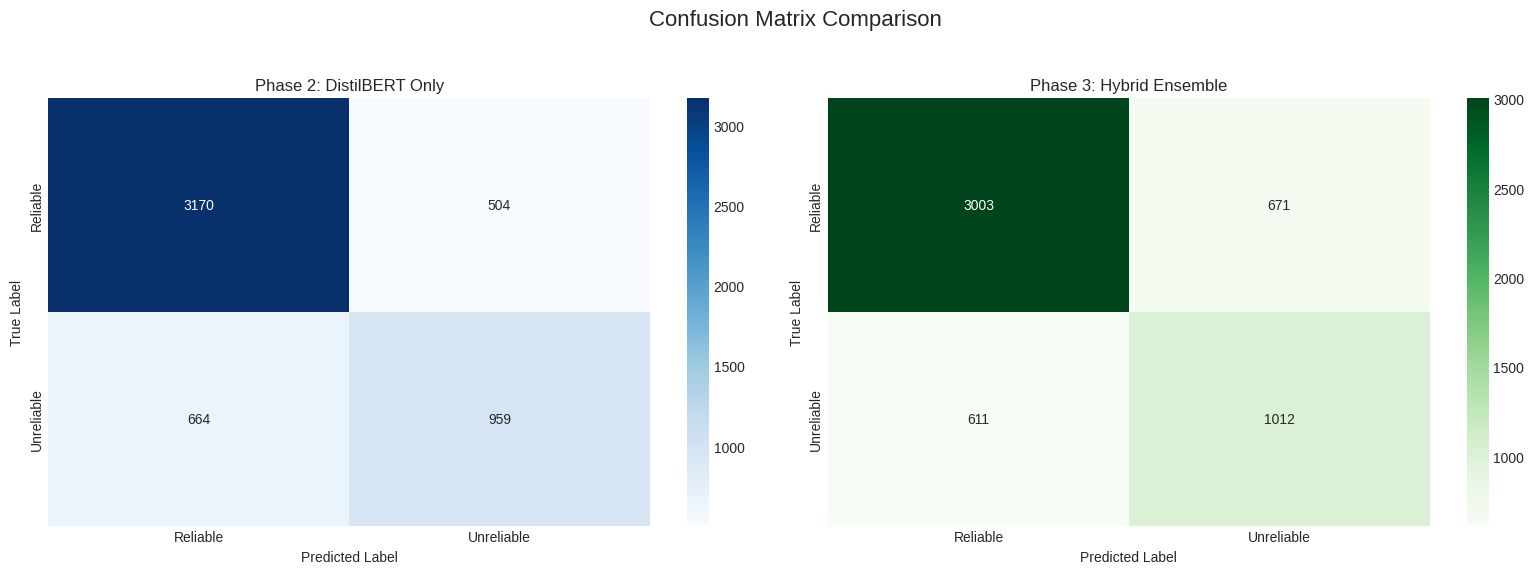

In [12]:
# --- Evaluate the new ensemble model on the test set ---
print("\nEvaluating Hybrid Ensemble Model on Test Set...")
y_pred_ensemble = ensemble_model.predict(X_test_texts, X_test_adv)
y_prob_ensemble = ensemble_model.predict_proba(X_test_texts, X_test_adv)

print("="*60)
print("Phase 3: Hybrid Ensemble Model - Classification Report")
print("="*60)
print(classification_report(y_test, y_pred_ensemble, target_names=['Reliable (0)', 'Unreliable (1)']))

# --- Load Phase 2 test results for comparison ---
phase2_results_path = "logs/test_results.json"
with open(phase2_results_path, 'r') as f:
    phase2_results = json.load(f)

# --- Compare Performance ---
phase2_f1_unreliable = phase2_results['f1_per_class'][1]
phase3_report = classification_report(y_test, y_pred_ensemble, output_dict=True)
phase3_f1_unreliable = phase3_report['1']['f1-score']
phase3_accuracy = accuracy_score(y_test, y_pred_ensemble)

print("\n" + "="*60)
print("PERFORMANCE COMPARISON: PHASE 2 vs PHASE 3")
print("="*60)
print(f"Phase 2 Accuracy (DistilBERT only): {phase2_results['accuracy']:.4f}")
print(f"Phase 3 Accuracy (Hybrid Ensemble):   {phase3_accuracy:.4f}\n")

print(f"Phase 2 F1-Score (Unreliable News): {phase2_f1_unreliable:.4f}")
print(f"Phase 3 F1-Score (Unreliable News): {phase3_f1_unreliable:.4f}\n")

improvement = phase3_f1_unreliable - phase2_f1_unreliable
print(f"Improvement in Unreliable News F1-Score: {improvement:+.4f} ({improvement/phase2_f1_unreliable:.2%})")
print("="*60)


# --- Visualize Confusion Matrices ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrix Comparison', fontsize=16)

# Phase 2 Confusion Matrix
# cm_phase2 = confusion_matrix(y_test, (np.array(phase2_results['f1_per_class']) > 0.5).astype(int)) # A placeholder, actual preds not saved
# We'll regenerate phase 2 preds for an accurate CM
phase2_preds_loader = DataLoader([{"text": t} for t in X_test_texts], batch_size=32)
phase2_preds_list = []
with torch.no_grad():
    for batch in phase2_preds_loader:
        inputs = tokenizer(batch['text'], return_tensors='pt', padding=True, truncation=True, max_length=512).to(device)
        outputs = distilbert_model(**inputs)
        phase2_preds_list.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
cm_phase2_accurate = confusion_matrix(y_test, phase2_preds_list)


sns.heatmap(cm_phase2_accurate, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Reliable', 'Unreliable'], yticklabels=['Reliable', 'Unreliable'])
axes[0].set_title('Phase 2: DistilBERT Only')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Phase 3 Confusion Matrix
cm_phase3 = confusion_matrix(y_test, y_pred_ensemble)
sns.heatmap(cm_phase3, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Reliable', 'Unreliable'], yticklabels=['Reliable', 'Unreliable'])
axes[1].set_title('Phase 3: Hybrid Ensemble')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [18]:
# --- Block 5 & 6: Explainable AI with LIME ---

def predict_proba_for_lime(texts):
    """
    Prediction function that LIME can use. It takes a list of raw texts
    and returns prediction probabilities from our full ensemble model.
    """
    # Create a temporary DataFrame to use our feature extractor
    temp_df = pd.DataFrame({'text_cleaned': texts})

    # 1. Extract advanced features
    adv_features = temp_df.progress_apply(feature_extractor.extract_all_features, axis=1)
    adv_features.fillna(0, inplace=True)

    # 2. Scale the features using the saved scaler
    scaled_adv_features = ensemble_model.feature_scaler.transform(adv_features)

    # 3. Get prediction probabilities from the ensemble
    probs = ensemble_model.predict_proba(texts, scaled_adv_features)

    return probs

# --- Initialize LIME Explainer ---
lime_explainer = LimeTextExplainer(class_names=['Reliable', 'Unreliable'])

# --- Test LIME on Sample Texts ---
test_samples = [
    {
        "text": "SHOCKING: Government hides TRUTH about aliens! Secret documents reveal extraterrestrial contact!",
        "expected": "Unreliable"
    },
    {
        "text": "The Reserve Bank of India announced a 0.25% increase in the repo rate, citing inflation concerns.",
        "expected": "Reliable"
    }
]

print("\n" + "="*60)
print("LIME EXPLANATION EXAMPLES")
print("="*60)

for i, sample in enumerate(test_samples):
    print(f"\n--- Explaining Sample {i+1} ---")
    print(f"Text: \"{sample['text']}\"")
    print(f"Expected Prediction: {sample['expected']}")

    # Generate the explanation
    explanation = lime_explainer.explain_instance(
        sample['text'],
        predict_proba_for_lime,
        num_features=8
    )

    # Display the prediction and explanation
    pred_probs = explanation.predict_proba
    pred_label = lime_explainer.class_names[pred_probs.argmax()]
    pred_confidence = pred_probs.max()

    print(f"Model Prediction: {pred_label} (Confidence: {pred_confidence:.2f})")
    print("\nKey words contributing to the prediction:")
    for word, weight in explanation.as_list():
        direction = "Unreliable" if weight > 0 else "Reliable"
        print(f" - '{word}': {abs(weight):.3f} (towards {direction})")

    # To visualize in a notebook, you can use:
    # explanation.show_in_notebook(text=True)


LIME EXPLANATION EXAMPLES

--- Explaining Sample 1 ---
Text: "SHOCKING: Government hides TRUTH about aliens! Secret documents reveal extraterrestrial contact!"
Expected Prediction: Unreliable


  0%|          | 0/5000 [00:00<?, ?it/s]

Getting DistilBERT Probs:   0%|          | 0/157 [00:00<?, ?it/s]

Model Prediction: Reliable (Confidence: 0.76)

Key words contributing to the prediction:
 - 'TRUTH': 0.236 (towards Reliable)
 - 'SHOCKING': 0.173 (towards Reliable)
 - 'hides': 0.109 (towards Reliable)
 - 'extraterrestrial': 0.100 (towards Unreliable)
 - 'reveal': 0.078 (towards Reliable)
 - 'Government': 0.063 (towards Reliable)
 - 'Secret': 0.048 (towards Reliable)
 - 'about': 0.024 (towards Reliable)

--- Explaining Sample 2 ---
Text: "The Reserve Bank of India announced a 0.25% increase in the repo rate, citing inflation concerns."
Expected Prediction: Reliable


  0%|          | 0/5000 [00:00<?, ?it/s]

Getting DistilBERT Probs:   0%|          | 0/157 [00:00<?, ?it/s]

Model Prediction: Unreliable (Confidence: 0.93)

Key words contributing to the prediction:
 - 'concerns': 0.085 (towards Unreliable)
 - 'Bank': 0.084 (towards Unreliable)
 - 'citing': 0.080 (towards Unreliable)
 - 'announced': 0.077 (towards Unreliable)
 - 'increase': 0.054 (towards Reliable)
 - 'inflation': 0.047 (towards Unreliable)
 - '0': 0.046 (towards Unreliable)
 - 'Reserve': 0.031 (towards Unreliable)
